In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from featuregraph import get_block_coordinates, get_valid_transformations, get_candidate_transformations, plot_arc_agi

In [ ]:
test_grid_1 = np.array([
    [8, 3],
    [0, 5],
])

test_grid_2 = np.array([
    [2, 7, 4],
    [9, 1, 6],
    [3, 8, 0],
])

test_grids = [
    test_grid_1,
    test_grid_2,
]

numeric_instruction_layout = np.array([
    [0, 1, 2],
    [2, 0, 1]
])
valid_transformations = get_valid_transformations(grid)
instruction_layout = np.array([[valid_transformations[i]['name'] for i in instruction] for instruction in numeric_instruction_layout])

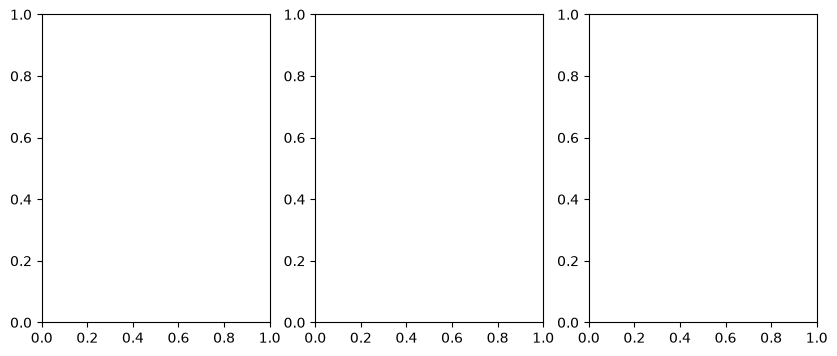

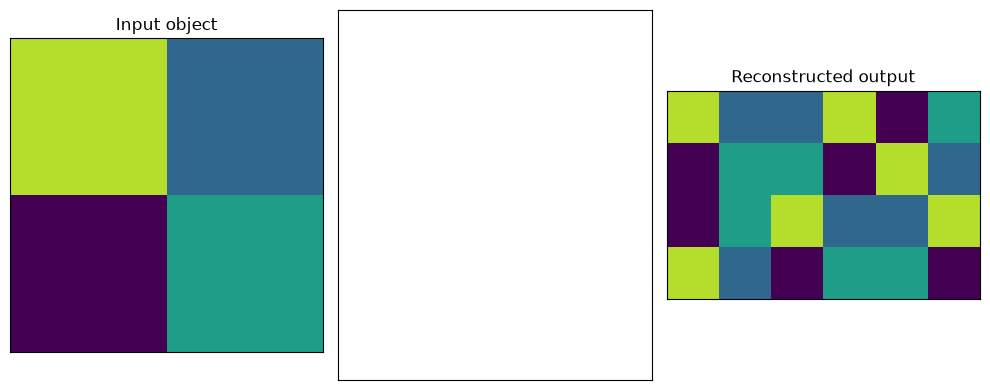

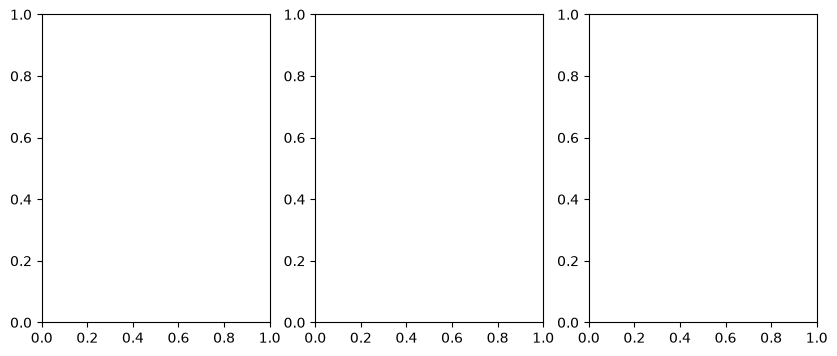

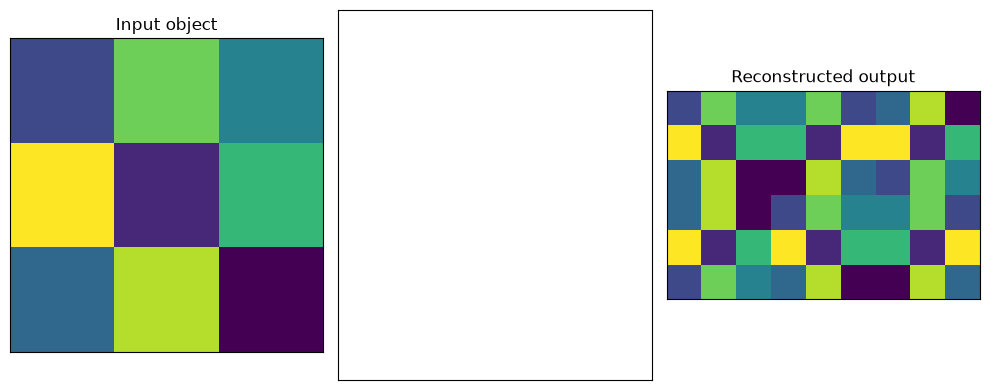

In [ ]:
predictions = []

for grid in test_grids:
    
    grid_flip_horizontal = np.fliplr(grid)
    grid_flip_vertical = np.flipud(grid)

    grid_height, grid_width = grid.shape
    predicted_height = instruction_layout.shape[0] * grid_height
    predicted_width = instruction_layout.shape[1] * grid_width
    predicted_shape = (predicted_height, predicted_width)

    number_of_block_rows = predicted_height // grid_height
    number_of_block_columns = predicted_width // grid_width

    block_coordinates = get_block_coordinates(grid.shape, predicted_shape)
    valid_transformations = get_valid_transformations(grid)
    candidate_transformations = np.array([get_candidate_transformations(v, block_coordinates) for v in valid_transformations]).T

    cell_indices = np.arange(candidate_transformations.shape[0])
    cell_instructions = numeric_instruction_layout[block_coordinates[:,0], block_coordinates[:,1]]
    manual_output = candidate_transformations[cell_indices, cell_instructions].reshape(predicted_shape)

    fig, axes = plt.subplots(1, 3, figsize=(10, 4))

    plot_arc_agi(grid, output=None, manual_output=manual_output)
    predictions.append(manual_output.copy())

In [ ]:
expected_test_output_1 = np.array([
    [8, 3, 3, 8, 0, 5],
    [0, 5, 5, 0, 8, 3],
    [0, 5, 8, 3, 3, 8],
    [8, 3, 0, 5, 5, 0],
])

In [ ]:
expected_test_output_2 = np.array([
    [2, 7, 4, 4, 7, 2, 3, 8, 0],
    [9, 1, 6, 6, 1, 9, 9, 1, 6],
    [3, 8, 0, 0, 8, 3, 2, 7, 4],
    [3, 8, 0, 2, 7, 4, 4, 7, 2],
    [9, 1, 6, 9, 1, 6, 6, 1, 9],
    [2, 7, 4, 3, 8, 0, 0, 8, 3],
])

In [ ]:
np.array_equal(
    predictions[0],
    expected_test_output_1,
)

True

In [ ]:
np.array_equal(
    predictions[1],
    expected_test_output_2,
)

True